# 6. Matrices de transición por ciclo ultradiano

Calcula matrices de transición separadas por **ciclo ultradiano** sobre la cohorte unificada (127 pacientes), para ver cómo cambia la dinámica del sueño conforme avanza la noche.

**Decisiones (a partir del diagnóstico del notebook 5):**
- Análisis principal: **ciclos 1–4** (cobertura ≥ 87% global, ≥ 82% por dataset).
- Anexo: ciclos 5–6 (cobertura 22–57%, N reducido).
- Fases: las 5 fisiológicas (0=Vigilia, 1=S1, 2=S2, 3=SWS, 4=REM); se excluye la fase 5 (Sin clasificar).
- Normalización: **por renglón** (probabilidad de salida desde cada fase). La matriz global ya se calcula en el notebook 4.

**Salidas** (en **imagenes/matrices_por_ciclo/** y **estadisticas/**):
- **ciclo_{n}_{global|cap|edf|sco}.png** — la matriz de cada ciclo y grupo.
- **evolucion_diagonal.png** — persistencia (diagonal) de cada fase a lo largo de los ciclos.
- **evolucion_s2_destinos.png** — destinos de salida de S2 (S2→SWS vs S2→REM) por ciclo.
- **matrices_ciclo_diagonal.csv** y **matrices_ciclo_s2_destinos.csv** — las tablas correspondientes.

In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path("..").resolve()
RUTA_CSV = RAIZ / "dataset/epocas_unificado.csv"
OUT_IMG  = RAIZ / "imagenes/matrices_por_ciclo"
OUT_EST  = RAIZ / "estadisticas"
OUT_IMG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RUTA_CSV)
print(f"Pacientes: {df['paciente'].nunique()} | Épocas: {len(df)}")

FASES = ['W', 'S1', 'S2', 'SWS', 'REM']  # índices 0..4; excluimos fase 5
N_FASES = 5
CICLOS_PRINCIPAL = [1, 2, 3, 4]
CICLOS_ANEXO     = [5, 6]
TODOS_CICLOS     = CICLOS_PRINCIPAL + CICLOS_ANEXO

Pacientes: 127 | Épocas: 112809


In [2]:
# Misma heurística del notebook 5: segmenta la noche en ciclos a partir de los periodos de REM.
def detectar_ciclos_rem(secuencia, fase_rem=4, umbral_separacion_rem_min=20, epocas_por_minuto=2):
    indices_rem = [i for i, x in enumerate(secuencia) if x == fase_rem]
    if not indices_rem:
        return []
    periodos_rem = []
    inicio_actual = indices_rem[0]
    fin_actual = indices_rem[0]
    for i in range(1, len(indices_rem)):
        distancia = indices_rem[i] - indices_rem[i-1]
        if distancia <= (umbral_separacion_rem_min * epocas_por_minuto):
            fin_actual = indices_rem[i]
        else:
            periodos_rem.append((inicio_actual, fin_actual))
            inicio_actual = indices_rem[i]
            fin_actual = indices_rem[i]
    periodos_rem.append((inicio_actual, fin_actual))
    ciclos = []
    inicio_ciclo = 0
    for p_inicio, p_fin in periodos_rem:
        ciclos.append((inicio_ciclo, p_fin))
        inicio_ciclo = p_fin + 1
    if inicio_ciclo < len(secuencia):
        ciclos.append((inicio_ciclo, len(secuencia) - 1))
    return ciclos

def matriz_renglon(transiciones):
    M = np.zeros((N_FASES, N_FASES), dtype=float)
    for a, b in transiciones:
        if 0 <= a < N_FASES and 0 <= b < N_FASES:
            M[a, b] += 1
    sumas = M.sum(axis=1, keepdims=True)
    sumas[sumas == 0] = 1
    return M / sumas, M  # probabilidades + conteos absolutos

print("Funciones listas.")

Funciones listas.


In [3]:
# Acumular transiciones por (dataset, num_ciclo)
trans_por_grupo = defaultdict(list)  # clave: (dataset, ciclo) o ('TODOS', ciclo)

for (ds, pac), g in df.groupby(["dataset", "paciente"], sort=False):
    seq = g.sort_values("epoca")["fase_num"].tolist()
    ciclos = detectar_ciclos_rem(seq, fase_rem=4)
    for num, (ini, fin) in enumerate(ciclos, start=1):
        sub = seq[ini:fin+1]
        bigramas = [(sub[i], sub[i+1]) for i in range(len(sub)-1)]
        trans_por_grupo[(ds, num)].extend(bigramas)
        trans_por_grupo[('TODOS', num)].extend(bigramas)

print("Grupos:", len(trans_por_grupo))
print("Ejemplo TODOS/Ciclo 1:", len(trans_por_grupo[('TODOS', 1)]), "transiciones")

Grupos: 29
Ejemplo TODOS/Ciclo 1: 28066 transiciones


In [4]:
def graficar_matriz(M, titulo, archivo):
    """Mismo estilo que notebook 4: cmap Blues, 3 decimales, texto completo."""
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(M, cmap='Blues')
    for i in range(N_FASES):
        for j in range(N_FASES):
            v = M[i, j]
            txt = '0' if v == 0 else (f'<0.001' if v < 0.001 else f'{v:.3f}')
            color = 'white' if v > M.max() * 0.6 else 'black'
            ax.text(j, i, txt, ha='center', va='center', color=color, fontsize=9)
    ax.set_xticks(range(N_FASES))
    ax.set_yticks(range(N_FASES))
    ax.set_xticklabels(FASES)
    ax.set_yticklabels(FASES)
    ax.set_xlabel("Fase destino")
    ax.set_ylabel("Fase origen")
    ax.set_title(titulo)
    fig.colorbar(im, ax=ax, shrink=0.85)
    fig.tight_layout()
    fig.savefig(archivo, dpi=300)
    plt.close(fig)

matrices = {}  # (grupo, ciclo) -> matriz probabilidades

for ciclo in TODOS_CICLOS:
    for grupo in ['TODOS', 'CAP', 'EDF', 'SCO']:
        clave = (grupo, ciclo)
        if clave not in trans_por_grupo or not trans_por_grupo[clave]:
            continue
        M, _ = matriz_renglon(trans_por_grupo[clave])
        matrices[clave] = M
        n_trans = len(trans_por_grupo[clave])
        nombre = f"ciclo_{ciclo}_{grupo.lower()}.png"
        graficar_matriz(M, f"Matriz por renglón - Ciclo {ciclo} - {grupo} ({n_trans:,} transiciones)", OUT_IMG / nombre)

print(f"Generadas {len(matrices)} matrices.")

Generadas 24 matrices.


In [5]:
# Tabla de persistencia (diagonal) por ciclo y grupo
filas = []
for (grupo, ciclo), M in matrices.items():
    for idx, fase in enumerate(FASES):
        filas.append(dict(grupo=grupo, ciclo=ciclo, fase=fase, p_permanencia=float(M[idx, idx])))
diag_df = pd.DataFrame(filas)
diag_df.to_csv(OUT_EST / "matrices_ciclo_diagonal.csv", index=False)

# Pivote para análisis principal (TODOS)
piv_global = (diag_df[diag_df.grupo == 'TODOS']
              .pivot(index='ciclo', columns='fase', values='p_permanencia')
              .loc[:, FASES])
print("Persistencia por fase (TODOS):")
print(piv_global.round(3))

Persistencia por fase (TODOS):
fase       W     S1     S2    SWS    REM
ciclo                                   
1      0.890  0.672  0.886  0.907  0.976
2      0.778  0.660  0.911  0.880  0.977
3      0.722  0.632  0.931  0.834  0.974
4      0.756  0.657  0.941  0.807  0.977
5      0.802  0.685  0.951  0.832  0.984
6      0.888  0.662  0.950  0.883  0.960


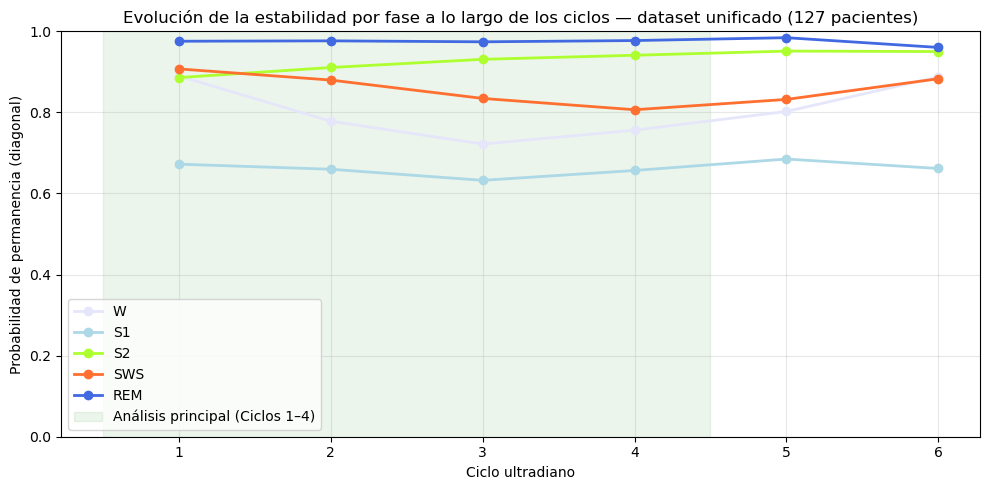

In [6]:
# Gráfico: evolución de la diagonal (persistencia por fase a lo largo de ciclos)
fig, ax = plt.subplots(figsize=(10, 5))
colores = {'W': '#E6E6FA', 'S1': '#ADD8E6', 'S2': '#ADFF2F', 'SWS': '#FF6F30', 'REM': '#4169E1'}
for fase in FASES:
    sub = diag_df[(diag_df.grupo == 'TODOS') & (diag_df.fase == fase)].sort_values('ciclo')
    ax.plot(sub['ciclo'], sub['p_permanencia'], marker='o', linewidth=2, color=colores[fase], label=fase)
ax.axvspan(0.5, 4.5, alpha=0.08, color='green', label='Análisis principal (Ciclos 1–4)')
ax.set_xlabel("Ciclo ultradiano")
ax.set_ylabel("Probabilidad de permanencia (diagonal)")
ax.set_title("Evolución de la estabilidad por fase a lo largo de los ciclos — dataset unificado (127 pacientes)")
ax.set_xticks(TODOS_CICLOS)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(OUT_IMG / "evolucion_diagonal.png", dpi=300)
plt.show()

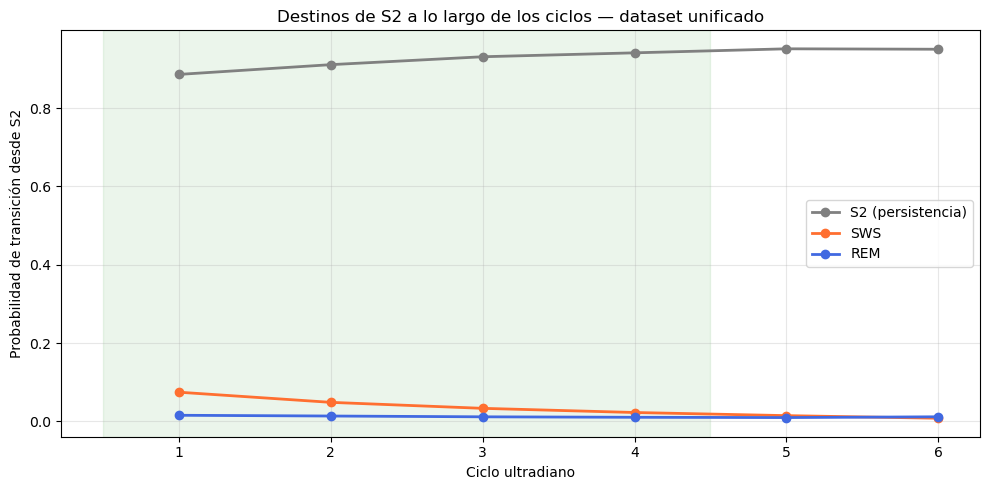

In [7]:
# Gráfico: destinos de S2 a lo largo de ciclos (S2→SWS vs S2→REM)
s2_dest = []
for (grupo, ciclo), M in matrices.items():
    if grupo != 'TODOS': continue
    s2_dest.append(dict(ciclo=ciclo, destino='SWS', p=float(M[2, 3])))
    s2_dest.append(dict(ciclo=ciclo, destino='REM', p=float(M[2, 4])))
    s2_dest.append(dict(ciclo=ciclo, destino='S2 (persistencia)', p=float(M[2, 2])))
s2_df = pd.DataFrame(s2_dest)
s2_df.to_csv(OUT_EST / "matrices_ciclo_s2_destinos.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
for dest, color in [('S2 (persistencia)', 'gray'), ('SWS', '#FF6F30'), ('REM', '#4169E1')]:
    sub = s2_df[s2_df.destino == dest].sort_values('ciclo')
    ax.plot(sub['ciclo'], sub['p'], marker='o', linewidth=2, color=color, label=dest)
ax.axvspan(0.5, 4.5, alpha=0.08, color='green')
ax.set_xlabel("Ciclo ultradiano")
ax.set_ylabel("Probabilidad de transición desde S2")
ax.set_title("Destinos de S2 a lo largo de los ciclos — dataset unificado")
ax.set_xticks(TODOS_CICLOS)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_IMG / "evolucion_s2_destinos.png", dpi=300)
plt.show()

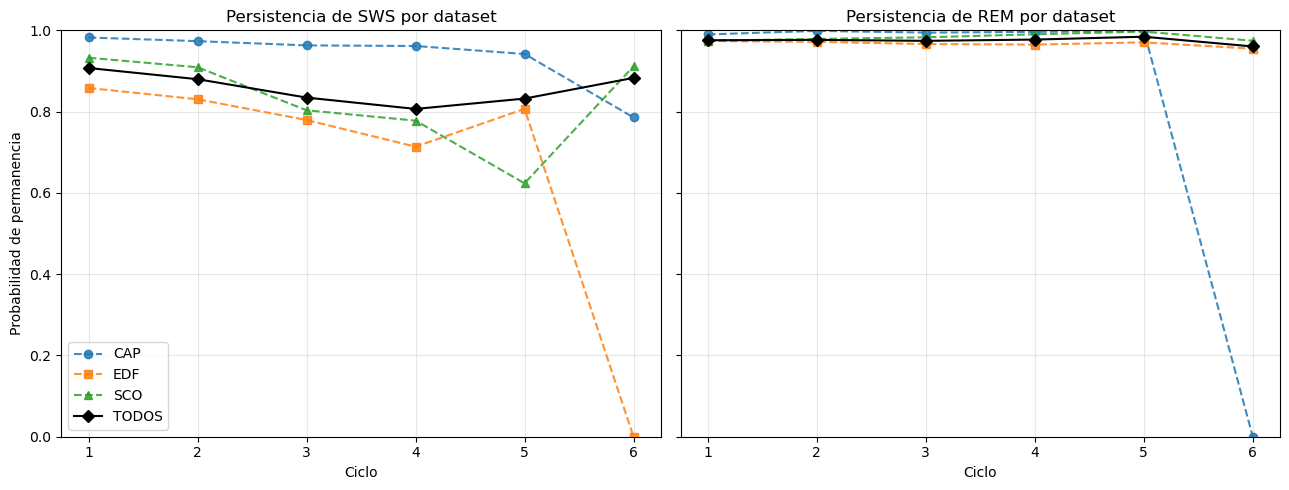

In [8]:
# Comparativo por dataset: persistencia de SWS y REM por ciclo
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, fase_obj in zip(axes, ['SWS', 'REM']):
    for grupo, color, marker in [('CAP', 'C0', 'o'), ('EDF', 'C1', 's'), ('SCO', 'C2', '^'), ('TODOS', 'k', 'D')]:
        sub = diag_df[(diag_df.grupo == grupo) & (diag_df.fase == fase_obj)].sort_values('ciclo')
        if not sub.empty:
            ax.plot(sub['ciclo'], sub['p_permanencia'], marker=marker, label=grupo, color=color,
                   linewidth=1.5, alpha=0.85 if grupo != 'TODOS' else 1.0,
                   linestyle='-' if grupo == 'TODOS' else '--')
    ax.set_xlabel("Ciclo")
    ax.set_title(f"Persistencia de {fase_obj} por dataset")
    ax.set_xticks(TODOS_CICLOS)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("Probabilidad de permanencia")
axes[0].legend()
plt.tight_layout()
plt.savefig(OUT_IMG / "comparativo_sws_rem_por_dataset.png", dpi=300)
plt.show()

In [9]:
# Resumen ejecutivo
print("=" * 60)
print("RESUMEN — Matrices por ciclo (Ciclos 1–4, análisis principal)")
print("=" * 60)
print("\nPersistencia por fase (TODOS):")
print(piv_global.loc[CICLOS_PRINCIPAL].round(3).to_string())
print("\nDestinos de S2 (TODOS):")
print(s2_df[s2_df.ciclo.isin(CICLOS_PRINCIPAL)]
      .pivot(index='ciclo', columns='destino', values='p').round(3).to_string())
print(f"\nArchivos generados en: {OUT_IMG}")
print(f"Tablas en: {OUT_EST}")

RESUMEN — Matrices por ciclo (Ciclos 1–4, análisis principal)

Persistencia por fase (TODOS):
fase       W     S1     S2    SWS    REM
ciclo                                   
1      0.890  0.672  0.886  0.907  0.976
2      0.778  0.660  0.911  0.880  0.977
3      0.722  0.632  0.931  0.834  0.974
4      0.756  0.657  0.941  0.807  0.977

Destinos de S2 (TODOS):
destino    REM  S2 (persistencia)    SWS
ciclo                                   
1        0.016              0.886  0.075
2        0.014              0.911  0.049
3        0.012              0.931  0.033
4        0.011              0.941  0.023

Archivos generados en: imagenes/matrices_por_ciclo
Tablas en: estadisticas


## Gráficas de publicación (versión final)

Versiones depuradas de las tres figuras de evolución por ciclo para el manuscrito: ejes **autoescalados**, foco en los **ciclos 1–5** (se omite el ciclo 6 por escasez muestral y valores degenerados) y, en los destinos de S2, se muestran solo las transiciones a SWS y REM para que su decaimiento sea visible. Sobrescriben los PNG usados en la tesis.

In [ ]:
# === Gráficas de publicación (versión final para la tesis) ===
# Se reconstruyen desde los CSV exportados arriba, con autoescala y enfoque en
# los ciclos 1–5 (se omite el ciclo 6 por su escasez muestral y valores degenerados).
diag_pub = pd.read_csv(OUT_EST / "matrices_ciclo_diagonal.csv")
s2_pub   = pd.read_csv(OUT_EST / "matrices_ciclo_s2_destinos.csv")
CICLOS_PUB = [1, 2, 3, 4, 5]
COL_FASE = {'W': '#9A86D4', 'S1': '#5BA3D0', 'S2': '#7BBF3A', 'SWS': '#FF6F30', 'REM': '#4169E1'}

# G1: estabilidad (diagonal) por fase, autoescalada
g1 = diag_pub[(diag_pub.grupo == 'TODOS') & (diag_pub.ciclo.isin(CICLOS_PUB))]
ymin = g1['p_permanencia'].min()
fig, ax = plt.subplots(figsize=(9, 5.4))
for f in FASES:
    s = g1[g1.fase == f].sort_values('ciclo')
    ax.plot(s['ciclo'], s['p_permanencia'], marker='o', lw=2.2, ms=7, color=COL_FASE[f], label=f)
ax.axvspan(0.5, 4.5, alpha=0.07, color='green')
ax.text(2.5, 1.005, 'Análisis principal (Ciclos 1–4)', ha='center', va='bottom', fontsize=9, color='green', alpha=0.85)
ax.set_xlabel("Ciclo ultradiano"); ax.set_ylabel("Probabilidad de permanencia")
ax.set_title("Estabilidad por fase a lo largo de los ciclos (127 pacientes)", pad=22)
ax.set_xticks(CICLOS_PUB); ax.set_ylim(ymin - 0.04, 1.0); ax.grid(alpha=0.3)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=5, framealpha=0.9, fontsize=10)
plt.tight_layout(); plt.savefig(OUT_IMG / "evolucion_diagonal.png", dpi=300, bbox_inches='tight'); plt.show()

# G2: destinos de salida de S2 (solo SWS y REM), con zoom y etiquetas
g2 = s2_pub[(s2_pub.destino.isin(['SWS', 'REM'])) & (s2_pub.ciclo.isin(CICLOS_PUB))]
fig, ax = plt.subplots(figsize=(9, 5))
for dest, color in [('SWS', '#FF6F30'), ('REM', '#4169E1')]:
    s = g2[g2.destino == dest].sort_values('ciclo')
    ax.plot(s['ciclo'], s['p'], marker='o', lw=2.4, ms=8, color=color, label=f'S2 → {dest}')
    for _, r in s.iterrows():
        ax.annotate(f"{r['p']:.3f}", (r['ciclo'], r['p']), textcoords="offset points",
                    xytext=(0, 8), ha='center', fontsize=8, color=color)
ax.set_xlabel("Ciclo ultradiano"); ax.set_ylabel("Probabilidad de transición desde S2")
ax.set_title("Destinos de salida de S2 a lo largo de los ciclos")
ax.set_xticks(CICLOS_PUB); ax.set_ylim(0, g2['p'].max() * 1.18); ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout(); plt.savefig(OUT_IMG / "evolucion_s2_destinos.png", dpi=300); plt.show()

# G3: persistencia de SWS y REM por base de datos, autoescalada
g3 = diag_pub[diag_pub.ciclo.isin(CICLOS_PUB)]
vals = g3[g3.fase.isin(['SWS', 'REM'])]['p_permanencia']
ylo = max(0, vals.min() - 0.05); yhi = min(1.02, vals.max() + 0.03)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, fase in zip(axes, ['SWS', 'REM']):
    for grupo, color, marker in [('CAP', 'C0', 'o'), ('EDF', 'C1', 's'), ('SCO', 'C2', '^'), ('TODOS', 'k', 'D')]:
        s = g3[(g3.grupo == grupo) & (g3.fase == fase)].sort_values('ciclo')
        if not s.empty:
            ax.plot(s['ciclo'], s['p_permanencia'], marker=marker, label=grupo, color=color,
                    lw=2 if grupo == 'TODOS' else 1.4, alpha=1 if grupo == 'TODOS' else 0.8,
                    linestyle='-' if grupo == 'TODOS' else '--')
    ax.set_xlabel("Ciclo"); ax.set_title(f"Persistencia de {fase} por base de datos")
    ax.set_xticks(CICLOS_PUB); ax.grid(alpha=0.3); ax.set_ylim(ylo, yhi)
axes[0].set_ylabel("Probabilidad de permanencia"); axes[0].legend(fontsize=9)
plt.tight_layout(); plt.savefig(OUT_IMG / "comparativo_sws_rem_por_dataset.png", dpi=300); plt.show()
print("Figuras de publicación regeneradas en", OUT_IMG)
